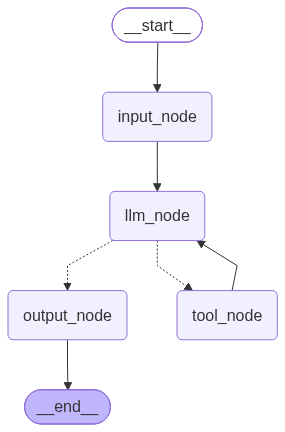

QueryRealTimeWeather调用失败
query_news调用失败
QueryRealTimeWeather调用成功
[2026-08-31 09:46:27] [INFO] [utils.logUtils:263] ####_run 查询 武汉 --101200101 的天气信息####
query_news调用成功
查询成功！以下是武汉今天（8月31日）的天气和新闻信息：

## 🌤️ 武汉今日天气
- **天气状况**：阴
- **气温**：28℃（体感温度 26℃）
- **风向风力**：东北风 5级（风速 33 km/h）
- **相对湿度**：53%
- **降水量**：0.0 mm（无降雨）
- **气压**：1005 百帕
- **能见度**：30 公里
- **云量**：0%
- **露点温度**：26℃

**小贴士**：今天天气阴沉，风力较大（5级东北风），出行请注意防风，湿度适中，体感较舒适。

## 📰 武汉今日新闻
1. **美女多达3000人** —— 关于武汉的趣味/话题新闻
2. **八一广场有美食活动** —— 武汉八一广场正在举办美食活动，吃货们可以关注一下
3. **房价起飞，直接翻倍！** —— 关于武汉房价上涨的新闻

如果您想进一步了解某条新闻的详情，或者查询其他城市/区县的天气，随时告诉我！


In [13]:

from langgraph.constants import START, END
from langchain_core.messages import HumanMessage, ToolMessage, SystemMessage
from typing import TypedDict, Literal
from langchain_core.tools import tool
from langgraph.graph import MessagesState, StateGraph
from numpy.random.mtrand import random_integers, randint
from IPython.display import display

from llm.llms import deepseek_llm, local_llm
from tools.weather_tools import QueryRealTimeWeather, QueryFuture7dWeather


@tool(parse_docstring=True)
def query_news(topic: str):
    """
    查询关于指定主题的新闻

    Args:
        topic: 新闻主题
    """
    return f"关于{topic}的新闻有：1. 美女多达3000人；2. 八一广场有美食活动； 3.房价起飞，直接翻倍！"


tools = [QueryRealTimeWeather(), query_news]

model_bind_tool = deepseek_llm.bind_tools(tools=tools)


class OverAllState(MessagesState):
    input_message: str
    output_message: str


def input_node(state: OverAllState) -> OverAllState:
    return {
        "messages": [HumanMessage(content=state["input_message"])]
    }


def output_node(state: OverAllState) -> OverAllState:
    return {
        "output_message": state["messages"][-1].content
    }


def llm_node(state: OverAllState) -> OverAllState:
    ai_message = model_bind_tool.invoke(input=state["messages"])
    return {
        "messages": ai_message
    }


def tool_node(state: OverAllState) -> OverAllState:
    try:
        messages = list(state["messages"])
        last_msg = messages[-1]
        for tool_call in last_msg.tool_calls:
            if tool_call["name"] == "query_news":
                if randint(0, 10) > 6:
                    print("query_news调用成功")
                    messages.append(query_news.invoke(tool_call))
                else:
                    print("query_news调用失败")
                    messages.append(ToolMessage
                                    (content="调用失败，请重试", tool_call_id=tool_call["id"])
                                    )
            elif tool_call["name"] == "QueryRealTimeWeather":
                if randint(0, 10) > 6:
                    print("QueryRealTimeWeather调用成功")
                    weather_tool = QueryRealTimeWeather()
                    messages.append(weather_tool.invoke(tool_call))
                else:
                    print("QueryRealTimeWeather调用失败")
                    messages.append(ToolMessage
                                    (content="调用失败，请重试", tool_call_id=tool_call["id"])
                                    )
        return {
            "messages": messages
        }
    except Exception as e:
        print(e)
        return None


def router(state: OverAllState) -> Literal["tool_node", "output_node"]:
    last_msg = state["messages"][-1]
    if last_msg.tool_calls:
        return "tool_node"
    return "output_node"


builder = StateGraph(state_schema=OverAllState)
builder.add_node(input_node)
builder.add_node(output_node)
builder.add_node(llm_node)
builder.add_node(tool_node)

builder.add_edge(START, "input_node")
builder.add_edge("input_node", "llm_node")
builder.add_conditional_edges("llm_node",router)
builder.add_edge("output_node", END)
builder.add_edge("tool_node", "llm_node")

graph = builder.compile()
display(graph)
result = graph.invoke({
    "input_message": "武汉今天的天气和新闻有哪些？",
    "messages": [SystemMessage("如果工具调用失败，必须重新调用工具直到成功为止")]
})
print(result["output_message"])



